In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,Annotated,List,Literal,Optional
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send
import operator
from langchain_core.messages import BaseMessage
from pathlib import Path
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_community.tools.tavily_search import TavilySearchResults
import os

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

HF_KEY = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

model_openai = ChatOpenAI(model = "gpt-4.1-mini")

llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation',
)

model_hf=ChatHuggingFace(llm=llm)

In [4]:
class Task(BaseModel):

    id : int
    title : str = Field(description = 'Title of the task')
    goal : str = Field(...,description="One sentence describing what the reader should be able to do/understand after this section.")
    bullets : List[str] = Field(...,min_length=3,max_length=5,description = "3–5 concrete, non-overlapping subpoints to cover in this section.")
    target_words : int = Field(...,description="Target word count for this section (120–450).")
    section_type : Literal["intro", "core", "examples", "checklist", "common_mistakes", "conclusion"] = Field(...,description="Use 'common_mistakes' exactly once in the plan.")

In [5]:
class Plan(BaseModel):

    blog_title : str = Field(description = 'Title of the blog')
    audience : str = Field(...,description = "Who this blog is for.")
    tone : str = Field(...,description ="Writing tone (e.g., practical, crisp).")
    blog_kind : Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraint : List[str] = Field(default_factory = list)
    task : List[Task]

In [6]:
class EvidenceItem(BaseModel):
    title : str
    url : str
    published_at : Optional[str]
    snippet : Optional[str]
    source : Optional[str]

In [7]:
class BlogState(TypedDict):

    topic : str
    mode : str
    needs_research : bool = Field(...,description = 'True or False')
    queries : List[str]
    evidence : List[EvidenceItem]

    plan : Optional[Plan]
    section : Annotated[List[tuple[int,str]],operator.add]
    final : str

In [8]:
def orchestrator(state:BlogState)->dict:
    
    topic = state['topic']

    model_with_structure = model_openai.with_structured_output(Plan)

    template = ChatPromptTemplate([
        ('system',"You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."),
        ('human',"topic : {topic}")
    ])

    chain = template | model_with_structure

    response = chain.invoke({'topic':topic})

    return {'plan':response}

In [9]:
def fanout(state:BlogState)->dict:

    topic = state['topic']
    plan = state['plan']
    mode = state['mode']
    evidence = state['evidence']

    return [Send('worker',{'task':task.model_dump(), 'topic':topic,'plan':plan.model_dump(),'mode' : mode,'evidence' : [e.model_dump() for e in evidence]}) for task in plan.task]

In [10]:
# Worker

def worker(payload : dict)->dict:

    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']
    evidence = payload['evidence']

    blog_title = plan['blog_title']
    section_type = task['section_type']
    audience = plan['audience']
    tone = plan['tone']
    task_title = task['title']
    goal = task['goal']
    bullet_text = '\n- ' + '\n-'.join(task['bullets'])
    target_words = task['target_words']

    evidence_text = ""
    for e in evidence:
        evidence_text = "\n".join(
            f"- {e['title']} | {e['url']} | {e['published_at'] or 'date:unknown'}".strip()
            for e in evidence[:20]
        )


    template = ChatPromptTemplate([
        ('system',"You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"),
        ('human',f"Blog: {blog_title}\n"
                    f"Audience: {audience}\n"
                    f"Tone: {tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task_title}\n"
                    f"Section type: {section_type}\n"
                    f"Goal: {goal}\n"
                    f"Target words: {target_words}\n"
                    f"Bullets:{bullet_text}\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n")
    ])

    chain = template | model_openai

    response = chain.invoke({'blog_title':blog_title,'audience':audience,'tone':tone,'topic':topic,'task_title':task_title,'section_type':section_type,'goal':goal,'target_words':target_words,'bullet_text':bullet_text})

    return {'section':[response.content]}

In [ ]:
def reducer(state:BlogState)->dict:

    plan = state['plan']
    title = plan.blog_title

    section = state['section']
    body = "\n\n".join(section).strip()

    final_md = f"# {title} \n\n {body}\n"

    #filename = title.lower().replace(' ','_')+'.md'
    filename = 'Future_of_ProWFM.md'
    output_path = Path(filename)
    output_path.write_text(final_md,encoding='utf-8')

    print("RAW TITLE:", repr(title))
    print("FILENAME:", repr(filename))

    return {'final':final_md}

In [12]:
# router

class RouterDecision(BaseModel):

    need_research : bool = Field(...,description = "True or False")
    mode : Literal["closed_book", "hybrid", "open_book"]
    queries : List[str] = Field(default_factory = list)

template = ChatPromptTemplate.from_messages([
    ('system',"""You are a routing module for a technical blog planner.

    Decide whether web research is needed BEFORE planning.

    Modes:
    - closed_book (needs_research=false):
    Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
    - hybrid (needs_research=true):
    Mostly evergreen but needs up-to-date examples/tools/models to be useful.
    - open_book (needs_research=true):
    Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

    If needs_research=true:
    - Output 3–10 high-signal queries.
    - Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
    - If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
    """),
    ('human',"Topic : {topic}")
])

print(template.input_variables)

model_with_structure = model_openai.with_structured_output(RouterDecision)

router_chain = template | model_with_structure

def router(state:BlogState)->dict:

    topic = state['topic']

    prompt = {'topic':topic}

    decision : RouterDecision = router_chain.invoke(prompt)

    return {
        'needs_research' : decision.need_research,
        'mode' : decision.mode,
        'queries' : decision.queries
    }

['topic']


In [13]:
def route_reflector(state : BlogState)->dict:

    needs_research = state['needs_research']

    if needs_research:
        return 'research'
    else:
        return 'orchestrator'

In [14]:
# research

class EvidencePack(BaseModel):

    evidence : List[EvidenceItem] = Field(default_factory = list)

template = ChatPromptTemplate([
    ('system',"""You are a research synthesizer for technical writing.

        Given raw web search results, produce a deduplicated list of EvidenceItem objects.

        Rules:
        - Only include items with a non-empty url.
        - Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
        - If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
        If missing or unclear, set published_at=null. Do NOT guess.
        - Keep snippets short.
        - Deduplicate by URL.
        """),
    ('human',"Raw result : {raw_result}")
],
input_variables = ['raw_result']
)

model_with_structure = model_openai.with_structured_output(EvidencePack)

research_chain = template | model_with_structure

# tavily function

def _tavily_search(query : str,max_results : int = 5):

    tool = TavilySearchResults(max_results = max_results)
    response = tool.invoke({'query' : query})

    normalized : List[dict] = []

    for res in response:
        normalized.append(
            {
                "title": res.get("title") or "",
                "url": res.get("url") or "",
                "snippet": res.get("content") or res.get("snippet") or "",
                "published_at": res.get("published_date") or res.get("published_at"),
                "source": res.get("source")
            }
        )
    
    return normalized


def research(state:BlogState)->dict:

    queries = state['queries']
    max_results = 6

    raw_result : List[dict] = []

    for query in queries:
        raw_result.extend(_tavily_search(query,max_results = max_results)) 

    if not raw_result:
        return {'evidence':[]}
    
    pack : EvidencePack = research_chain.invoke({'raw_result':raw_result})

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}
    


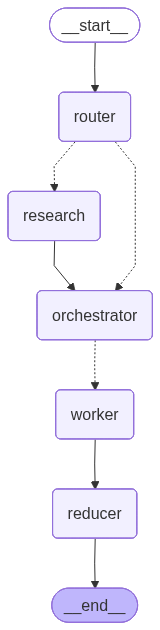

In [15]:
graph = StateGraph(BlogState)

graph.add_node('router',router)
graph.add_node('research',research)
graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)

graph.add_edge(START,'router')
graph.add_conditional_edges('router',route_reflector,{'research':'research','orchestrator':'orchestrator'})
graph.add_edge('research','orchestrator')
graph.add_conditional_edges('orchestrator',fanout,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)

blog = graph.compile()

blog

In [17]:
response = blog.invoke({'topic':'Future of ProWFM (Workforce Management) UKG'})

print(response)

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(need_resea...tions like UKG ProWFM']), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(
c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvidencePack(evidence=[Ev...iences.', source=None)]), input_type=EvidencePack])
  return self.__pydantic_serializer__.to_python(
c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expecte

RAW TITLE: "Exploring the Future of ProWFM: UKG's Workforce Management Evolution"
FILENAME: 'top_ai_news_in_february_2026.md'
{'topic': 'Future of ProWFM (Workforce Management) UKG', 'mode': 'hybrid', 'needs_research': True, 'queries': ['Future trends in ProWFM workforce management systems', 'Upcoming features and roadmap for UKG ProWFM', 'UKG ProWFM integration with AI and machine learning', 'Case studies on UKG ProWFM implementations in 2024', 'Customer feedback and reviews on UKG ProWFM latest updates', 'Comparison of UKG ProWFM with other workforce management platforms', 'Impact of automation on workforce management solutions like UKG ProWFM'], 'evidence': [EvidenceItem(title='Workforce Management Trends 2026 - How are staff scheduling and ...', url='https://timegrip.com/insights/workforce-management-trends-2026-how-are-staff-scheduling-and-time-tracking-evolving-and-how-is-ai-influencing-this-development/', published_at=None, snippet='Workforce Management is becoming increasingly 

In [16]:
response['section']

['## Introduction and February 2026 AI Landscape Overview\n\nFebruary 2026 marked a pivotal month in AI with impactful breakthroughs across model architecture, hardware, and regulatory frameworks. Key announcements included the release of advanced multimodal models that seamlessly integrate text, vision, and audio inputs, exemplified by GPT-5.2 and Claude Opus 4.6, enhancing capabilities for natural language understanding and generation with richer context. Concurrently, next-gen AI hardware rolled out, boasting specialized neural accelerators that optimize both training speed and inference latency, crucial for deploying AI at scale in real-time applications.\n\nThese innovations promise to reshape developer workflows by enabling more efficient model integration, reducing compute costs, and broadening AI application domains such as autonomous manufacturing systems, creative content generation, and real-time data analytics. The proliferation of multimodal AI sets a new standard for desi